# AI-Driven Phishing Email Detection Using Natural Language Processing (NLP)

### Indian Institute of Computing and Technology (IICT)

---

## Project Objective

The objective of this project is to develop a Machine Learning model capable of automatically classifying emails as **Phishing** or **Legitimate** using Natural Language Processing (NLP).

The project involves data preprocessing, feature extraction using TF-IDF, training multiple Machine Learning algorithms, and evaluating their performance using standard classification metrics.

---

## Project Workflow

The project follows the following pipeline:

1. Import Required Libraries
2. Load and Explore Dataset
3. Data Cleaning
4. Exploratory Data Analysis
5. Text Preprocessing
6. Feature Extraction using TF-IDF
7. Model Training
8. Model Evaluation
9. Model Comparison
10. Save Trained Models

# Step 1 : Import Required Libraries

Before building the phishing email detection system, we first import all the Python libraries required throughout the project.

These libraries are used for:

- Data manipulation
- Data visualization
- Text preprocessing
- Feature extraction
- Machine Learning model development
- Performance evaluation

In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk joblib

In [1]:
import pandas as pd
print(pd.__version__)

3.0.5


In [2]:
import sys
print(sys.version)

3.13.0 (tags/v3.13.0:60403a5, Oct  7 2024, 09:38:07) [MSC v.1941 64 bit (AMD64)]


In [3]:
import sys
print(sys.executable)

D:\IICT Projects\Project 2\.venv\Scripts\python.exe


In [4]:
!pip --version

pip 26.2 from D:\IICT Projects\Project 2\.venv\Lib\site-packages\pip (python 3.13)



In [1]:
# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Text Processing
import re
import string

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Toolkit
import nltk
from nltk.corpus import stopwords

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Save Models
import joblib

# Download Stopwords
nltk.download('stopwords')

print("All libraries imported successfully.")

All libraries imported successfully.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Step 2: Loading the Dataset

In this step, we load the phishing email dataset into a Pandas DataFrame.
After loading the dataset, we will examine its dimensions and preview a few records to ensure the data has been imported successfully.

In [2]:
# Load Dataset

df = pd.read_csv("phishing_email.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
df.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [4]:
rows, cols = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {cols}")

Number of Rows    : 82486
Number of Columns : 2


In [5]:
df.columns

Index(['text_combined', 'label'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 82486 entries, 0 to 82485
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   text_combined  82486 non-null  str  
 1   label          82486 non-null  int64
dtypes: int64(1), str(1)
memory usage: 1.3 MB


In [7]:
df.describe(include="all")

,text_combined,label
count,82486,82486.000000
unique,82078,NaN
top,charity sees need cost dear friend read want f...,NaN
freq,3,NaN
mean,NaN,0.519979
std,NaN,0.499604
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,1.000000
75%,NaN,1.000000


# Step 3: Dataset Quality Check

This step examines the dataset for missing values, duplicate records, and class distribution before preprocessing.

## Missing Values

Check whether the dataset contains any null values.

In [8]:
missing_values = df.isnull().sum()

missing_values

text_combined    0
label            0
dtype: int64

In [9]:
missing_df = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values
})

missing_df

,Column,Missing Values
0,text_combined,0
1,label,0


## Duplicate Records

Check whether the dataset contains duplicate email records before model training.

In [10]:
duplicate_count = df.duplicated().sum()

print("Duplicate Records :", duplicate_count)

Duplicate Records : 408


In [11]:
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed successfully.")
else:
    print("No duplicate records found.")

Duplicates removed successfully.


## Class Distribution

Analyze the distribution of phishing and legitimate emails in the dataset.

In [12]:
class_counts = df["label"].value_counts()

class_counts

label
1    42845
0    39233
Name: count, dtype: int64

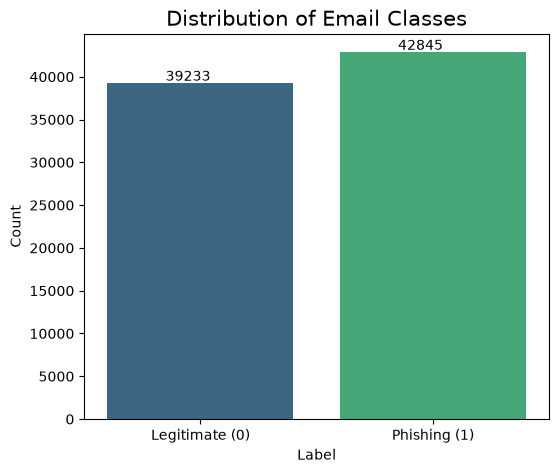

In [13]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="label",
    palette="viridis"
)

plt.title("Distribution of Email Classes", fontsize=15)
plt.xlabel("Label")
plt.ylabel("Count")

ax.set_xticklabels(["Legitimate (0)", "Phishing (1)"])

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x()+0.25, p.get_height()+300)
    )

plt.show()

## Text Analysis

Analyze the length of email messages after preprocessing.

In [ ]:
df["text_length"] = df["clean_text"].apply(len)

In [ ]:
df["text_length"].describe()

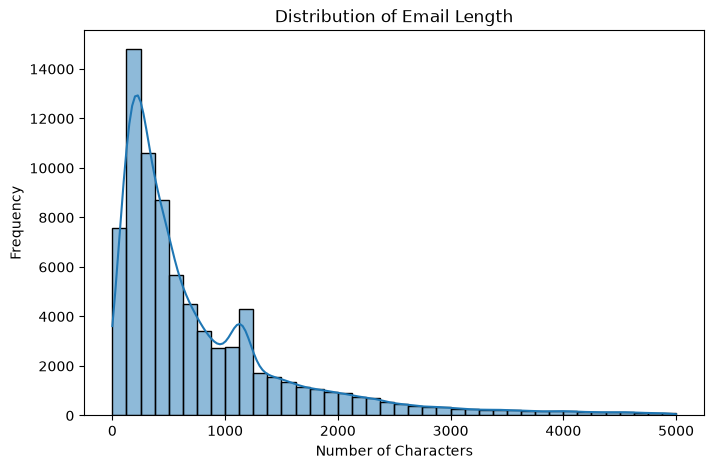

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    df[df["text_length"] < 5000]["text_length"],
    bins=40,
    kde=True
)

plt.title("Distribution of Email Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

# Step 4: Text Preprocessing

Clean the email text by removing unnecessary characters and common words to prepare it for feature extraction.

In [16]:
stop_words = set(stopwords.words("english"))

In [17]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [18]:
df["clean_text"] = df["text_combined"].apply(clean_text)

In [19]:
df[["text_combined", "clean_text"]].head()

,text_combined,clean_text
0,hpl nom may 25 2001 see attached file hplno 52...,hpl nom may see attached file hplno xls hplno xls
1,nom actual vols 24 th forwarded sabrae zajac h...,nom actual vols th forwarded sabrae zajac hou ...
2,enron actuals march 30 april 1 201 estimated a...,enron actuals march april estimated actuals ma...
3,hpl nom may 30 2001 see attached file hplno 53...,hpl nom may see attached file hplno xls hplno xls
4,hpl nom june 1 2001 see attached file hplno 60...,hpl nom june see attached file hplno xls hplno...


In [20]:
df.columns

Index(['text_combined', 'label', 'clean_text'], dtype='str')

In [21]:
"clean_text" in df.columns

True

In [22]:
try:
    print(X_train.shape)
except:
    print("X_train does not exist")

X_train does not exist


# Step 5: Feature Engineering

Convert the cleaned email text into numerical features using the TF-IDF (Term Frequency-Inverse Document Frequency) technique.

TF-IDF assigns higher importance to informative words while reducing the impact of frequently occurring words.

In [23]:
vectorizer = TfidfVectorizer(
    max_features=5000
)

X = vectorizer.fit_transform(df["clean_text"])

y = df["label"]

In [24]:
print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (82078, 5000)
Target Shape : (82078,)


## Train-Test Split

Split the dataset into training and testing sets for model development and evaluation.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 65662
Testing Samples : 16416


## Feature Preview

Display a few TF-IDF features generated from the email text.

In [27]:
feature_names = vectorizer.get_feature_names_out()

pd.DataFrame(feature_names, columns=["TF-IDF Features"]).head(20)

,TF-IDF Features
0,aa
1,aaron
2,ab
3,abacha
4,abandoned
5,abidjan
6,ability
7,able
8,abroad
9,absence


# Step 6: Model Development

Train and evaluate multiple Machine Learning algorithms for phishing email classification.

## Logistic Regression

Train a Logistic Regression model using the TF-IDF features.

In [28]:
lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [29]:
y_pred_lr = lr_model.predict(X_test)

In [30]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print()

print(classification_report(y_test, y_pred_lr))

Accuracy : 0.9799585769980507

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7847
           1       0.98      0.98      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



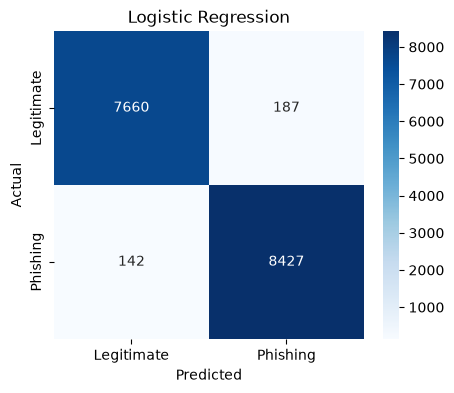

In [39]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Phishing"],
    yticklabels=["Legitimate","Phishing"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression")

plt.show()

## Multinomial Naive Bayes

Train a Multinomial Naive Bayes classifier using TF-IDF features.

In [31]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[31386.,34276.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.74,-0.65]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 5000)","[[ 18.35, 53.04, 14.78,..., 18.77, 0.9 ,148.91], [ 22.04, 5.61, 25.62,..., 25.36, 63.69, 0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 5000)","[[ -9.26, -8.23, -9.46,..., -9.24,-11.58, -7.21], [ -9.06,-10.3 , -8.91,..., -8.92, -8.02,-12.19]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


In [32]:
y_pred_nb = nb_model.predict(X_test)

In [33]:
print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print()

print(classification_report(y_test, y_pred_nb))

Accuracy : 0.9596734892787524

              precision    recall  f1-score   support

           0       0.94      0.97      0.96      7847
           1       0.98      0.95      0.96      8569

    accuracy                           0.96     16416
   macro avg       0.96      0.96      0.96     16416
weighted avg       0.96      0.96      0.96     16416



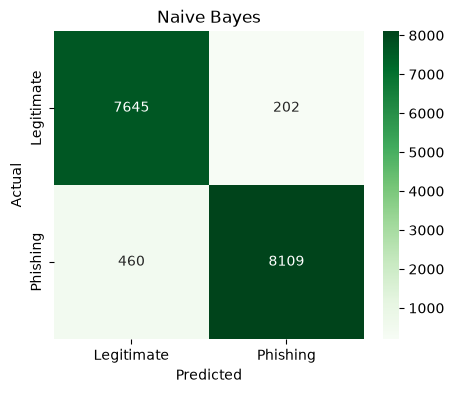

In [43]:
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Legitimate","Phishing"],
    yticklabels=["Legitimate","Phishing"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes")

plt.show()

## Random Forest

Train a Random Forest classifier using the TF-IDF features.

In [40]:
rf_model = RandomForestClassifier(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

In [41]:
import time

start = time.time()

rf_model.fit(X_train, y_train)

end = time.time()

print(f"Training completed in {end-start:.2f} seconds")

Training completed in 10.23 seconds


In [42]:
y_pred_rf = rf_model.predict(X_test)

In [43]:
X_train.shape

(65662, 5000)

In [44]:
type(X_train)

scipy.sparse._csr.csr_matrix

In [45]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print()

print(classification_report(y_test, y_pred_rf))

Accuracy : 0.9778874269005848

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      7847
           1       0.98      0.97      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



In [48]:
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(lr_model, "logistic_regression.pkl")
joblib.dump(nb_model, "naive_bayes.pkl")
joblib.dump(rf_model, "random_forest.pkl")

['random_forest.pkl']

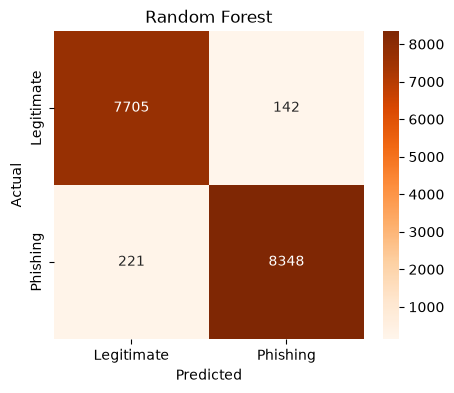

In [49]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Legitimate","Phishing"],
    yticklabels=["Legitimate","Phishing"]
)

plt.title("Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Neural Network

Train a Multi-Layer Perceptron (MLP) classifier using TF-IDF features.

In [53]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=10,
    early_stopping=True,
    random_state=42
)

mlp_model.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50,)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",10
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the w

In [54]:
y_pred_mlp = mlp_model.predict(X_test)

In [55]:
print("Accuracy :", accuracy_score(y_test, y_pred_mlp))
print()

print(classification_report(y_test, y_pred_mlp))

Accuracy : 0.9828216374269005

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7847
           1       0.98      0.98      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



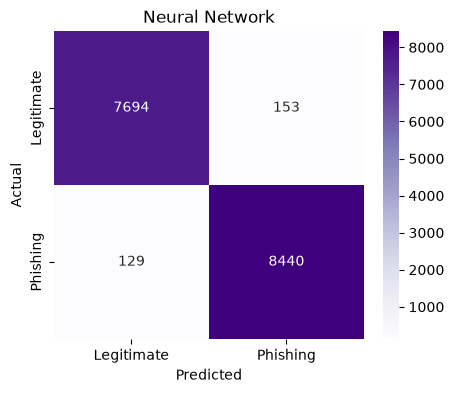

In [56]:
cm = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Legitimate","Phishing"],
    yticklabels=["Legitimate","Phishing"]
)

plt.title("Neural Network")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [57]:
joblib.dump(mlp_model, "neural_network.pkl")

['neural_network.pkl']

# Step 7: Model Comparison

Compare the performance of all Machine Learning models using standard evaluation metrics.

In [58]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest",
        "Neural Network"
    ],
    "Accuracy":[
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_mlp)
    ],
    "Precision":[
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_mlp)
    ],
    "Recall":[
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_mlp)
    ],
    "F1-Score":[
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_mlp)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.979959,0.978291,0.983429,0.980853
1,Naive Bayes,0.959673,0.975695,0.946318,0.960782
2,Random Forest,0.977887,0.983274,0.974209,0.978721
3,Neural Network,0.982822,0.982195,0.984946,0.983568


In [59]:
results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1-Score
0,Neural Network,0.982822,0.982195,0.984946,0.983568
1,Logistic Regression,0.979959,0.978291,0.983429,0.980853
2,Random Forest,0.977887,0.983274,0.974209,0.978721
3,Naive Bayes,0.959673,0.975695,0.946318,0.960782


### Accuracy Comparison

The following chart compares the accuracy achieved by each machine learning model.

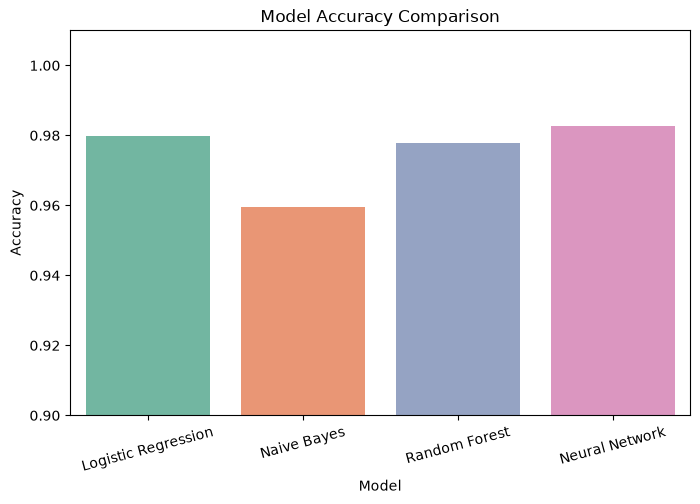

In [60]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    palette="Set2"
)

plt.ylim(0.9,1.01)
plt.xticks(rotation=15)

plt.title("Model Accuracy Comparison")

plt.show()

### Precision, Recall and F1-Score Comparison

Compare the performance of all models using multiple evaluation metrics.

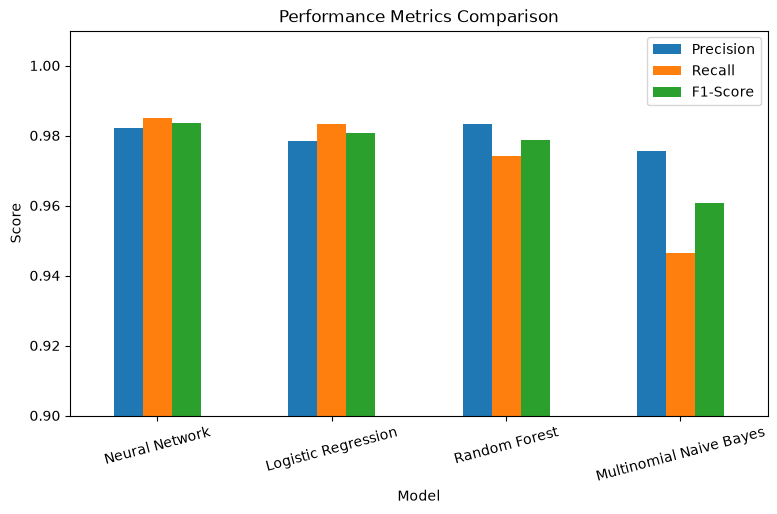

In [66]:
metrics = comparison.set_index("Model")[["Precision","Recall","F1-Score"]]

metrics.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Performance Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0.90,1.01)
plt.xticks(rotation=15)

plt.show()

### Best Performing Model

The model with the highest accuracy is selected as the final phishing email classifier.

In [68]:
best_model = comparison.iloc[0]

print("Best Model :", best_model["Model"])
print("Accuracy   :", round(best_model["Accuracy"]*100,2), "%")

Best Model : Neural Network
Accuracy   : 98.28 %


# Step 8: Saving Trained Models

Save the trained models and TF-IDF vectorizer for future prediction.

In [69]:
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

joblib.dump(lr_model, "logistic_regression.pkl")

joblib.dump(nb_model, "naive_bayes.pkl")

joblib.dump(rf_model, "random_forest.pkl")

joblib.dump(mlp_model, "neural_network.pkl")

print("Models saved successfully.")

Models saved successfully.


# Conclusion

An AI-driven phishing email detection system was successfully developed using Natural Language Processing and Machine Learning.

The email dataset was cleaned, transformed using TF-IDF, and evaluated using four classification algorithms:

- Logistic Regression
- Multinomial Naive Bayes
- Random Forest
- Neural Network

The models were assessed using Accuracy, Precision, Recall, and F1-Score. The comparative analysis identified the best-performing classifier for phishing email detection.

This project demonstrates the effectiveness of NLP-based Machine Learning techniques in identifying phishing emails.

# Future Scope

- Integrate the model into an email client for real-time phishing detection.
- Explore advanced deep learning models such as LSTM and BERT.
- Expand the dataset with recent phishing email samples.
- Develop a web-based interface for live email classification.